# <center> Topic 1. Exploratory data analysis with Pandas
## <center>Practice. Analyzing "Titanic" passengers

**Fill in the missing code ("You code here").**

Практическую работу выполнил студент Андрющенко К.С.

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Graphics in SVG format are more sharp and legible
%config InlineBackend.figure_format = 'svg'
pd.set_option("display.precision", 2)

```%config InlineBackend.figure_format = 'svg'``` указывает, что все графики, создаваемые в ячейках, должны отображаться в формате SVG.  
```pd.set_option("display.precision", 2)``` изменяет настройку отображения чисел в pandas.

**Read data into a Pandas DataFrame**

In [2]:
data = pd.read_csv("titanic_train.csv", index_col="PassengerId")

**First 5 rows**

In [3]:
data.head(5)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.28,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.10,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S


In [4]:
data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


```data.describe()``` Выполняет создание описательной статистики.
Описательная статистика включает в себя статистику, которая суммирует центральную тенденцию, дисперсию и форму распределения набора данных, за исключением NaN значений.

**Let's select those passengers who embarked in Cherbourg (Embarked=C) and paid > 200 pounds for their ticker (fare > 200).**

Make sure you understand how actually this construction works.

In [5]:
data[(data["Embarked"] == "C") & (data.Fare > 200)].head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
119,0,1,"Baxter, Mr. Quigg Edmond",male,24.0,0,1,PC 17558,247.52,B58 B60,C
259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.33,NaN,C
300,1,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.0,0,1,PC 17558,247.52,B58 B60,C
312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.38,B57 B59 B63 B66,C
378,0,1,"Widener, Mr. Harry Elkins",male,27.0,0,2,113503,211.50,C82,C


**We can sort these people by Fare in descending order.**

In [6]:
data[(data["Embarked"] == "C") & (data["Fare"] > 200)].sort_values(
    by="Fare", ascending=False
).head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.33,NaN,C
680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.33,B51 B53 B55,C
738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.33,B101,C
312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.38,B57 B59 B63 B66,C
743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.38,B57 B59 B63 B66,C


```ascending``` - cортировать по возрастанию или по убыванию.

**Let's create a new feature.**

In [7]:
def age_category(age):
    """
    < 30 -> 1
    >= 30, <55 -> 2
    >= 55 -> 3
    """
    if age < 30:
        return 1
    elif age < 55:
        return 2
    elif age >= 55:
        return 3

In [8]:
age_categories = [age_category(age) for age in data.Age]
data["Age_category"] = age_categories

**Another way is to do it with `apply`.**

In [9]:
data["Age_category"] = data["Age"].apply(age_category)

```data["Age"].apply(age_category)``` применить функцию () вдоль оси DataFrame.

Объекты, переданные в функцию, являются объектами Series, индекс которых является либо индексом DataFrame ( axis=0), либо столбцами DataFrame ( axis=1). По умолчанию ( result_type=None) окончательный тип возвращаемого значения выводится из типа возвращаемого значения примененной функции. В противном случае он зависит от аргумента result_type.

**1. How many men/women were there onboard?**
- 412 men and 479 women
- 314 men and 577 women
- 479 men and 412 women
- 577 men and 314 women

```value_counts()``` возвращает количество уникальных значений в указанном столбце.

In [10]:
# You code here
data['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

Значит, на борту 577 мужчин (men) и 314 женщин (women)

**2. Print the distribution of the `Pclass` feature. Then the same, but for men and women separately. How many men from second class were there onboard?**
- 104
- 108
- 112
- 125

Построение столбчатой диограммы, отражающей распределение значений в ```Pclass```

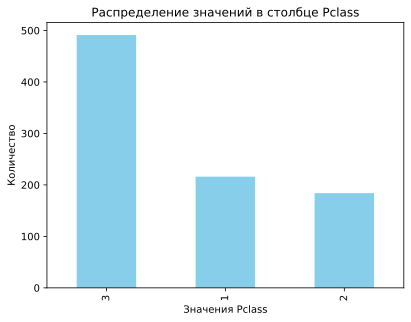

In [11]:
pclass_counts = data['Pclass'].value_counts()
pclass_counts.plot(kind='bar', color='skyblue')
plt.title('Распределение значений в столбце Pclass')
plt.xlabel('Значения Pclass')
plt.ylabel('Количество')

plt.show()

Или тоже самое, только с ```seaborn```

/tmp/ipykernel_196269/2551075834.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=data, palette='pastel')


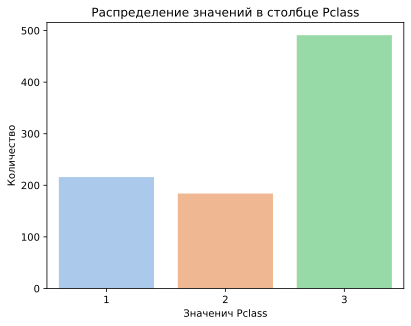

In [12]:
import seaborn as sns

sns.countplot(x='Pclass', data=data, palette='pastel')
plt.title('Распределение значений в столбце Pclass')
plt.xlabel('Значенич Pclass')
plt.ylabel('Количество')

plt.show()

Построим отдельные графики для мужчин и для женищин.

/tmp/ipykernel_196269/189217766.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=female_data, palette='pastel')


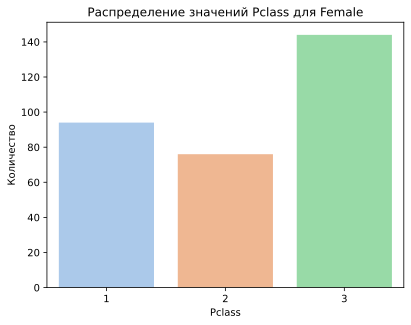

In [13]:
# только для женщин
female_data = data[(data["Sex"] == "female")]
sns.countplot(x='Pclass', data=female_data, palette='pastel')
plt.title('Распределение значений Pclass для Female')
plt.xlabel('Pclass')
plt.ylabel('Количество')

plt.show()

/tmp/ipykernel_196269/4032323619.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  x = sns.countplot(x='Pclass', data=men_data, palette='pastel')


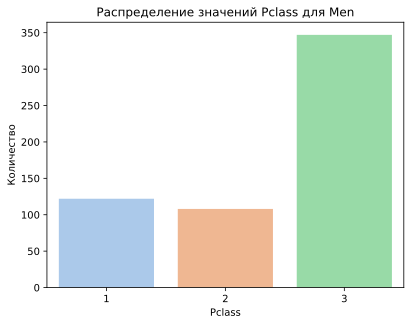

In [14]:
# только для мужчин
men_data = data[(data["Sex"] == "male")]
x = sns.countplot(x='Pclass', data=men_data, palette='pastel')
plt.title('Распределение значений Pclass для Men')
plt.xlabel('Pclass')
plt.ylabel('Количество')

plt.show()

Для того, чтобы точно узнать сколько мужчин второго класса было на борту, добавим надписи к столбцам.

/tmp/ipykernel_196269/784640087.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  x = sns.countplot(x='Pclass', data=men_data, palette='pastel')


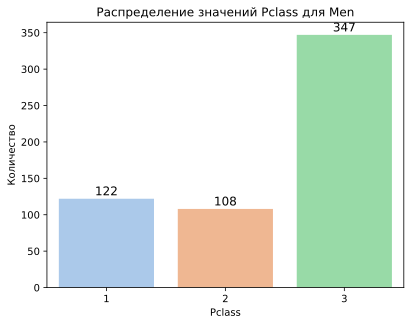

In [15]:
# только для мужчин
men_data = data[(data["Sex"] == "male")]
x = sns.countplot(x='Pclass', data=men_data, palette='pastel')
plt.title('Распределение значений Pclass для Men')
plt.xlabel('Pclass')
plt.ylabel('Количество')
for p in x.patches:
    x.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 1), 
                textcoords='offset points')
plt.show()

Из графика распределения видно, что количество мужчин второго класса на борту равно 108.

**3. What are median and standard deviation of `Fare`?. Round to two decimals.**
- median is  14.45, standard deviation is 49.69
- median is 15.1, standard deviation is 12.15
- median is 13.15, standard deviation is 35.3
- median is  17.43, standard deviation is 39.1

```std()``` вычисляет стандартное отклонение для каждого столбца. 

In [16]:
# стандартное отклонение
round(data['Fare'].std(), 2)

49.69

In [17]:
# медиана
round(data['Fare'].median(), 2)

14.45

Медиана равна 14.45, а отклонение 49.69

**4. Is that true that the mean age of survived people is higher than that of passengers who eventually died?**
- Yes
- No


Посчитаем средний возраст у пассажиров, которые выжили (Survived = 1) и у пассажиров, которые умерли и сравним.

In [18]:
# средний возраст выживших
survived = round(data[(data['Survived'] == 1)]['Age'].mean(), 2)
# средний возраст умерших
dead = round(data[(data['Survived'] == 0)]['Age'].mean(), 2)
print(survived, dead)
# chfdytyb
if survived > dead:
    print("Yes")
else:
    print("No")

28.34 30.63
No


**5. Is that true that passengers younger than 30 y.o. survived more frequently than those older than 60 y.o.? What are shares of survived people among young and old people?**
- 22.7% among young and 40.6% among old
- 40.6% among young and 22.7% among old
- 35.3% among young and 27.4% among old
- 27.4% among young and  35.3% among old

In [19]:
# dctuj
yang = data[(data['Age'] < 30)]['Age'].count()
old = data[(data['Age'] > 60)]['Age'].count()
# доля молодых
yang_p = data[(data['Survived'] == 1) & (data['Age'] < 30)]['Age'].count()
# доля пожилых
old_p = data[(data['Survived'] == 1) & (data['Age'] > 60)]['Age'].count()
print("Доля молодых ","{:.1%}".format(yang_p/yang))
print("Доля пожилых ","{:.1%}".format(old_p/old))

Доля молодых  40.6%
Доля пожилых  22.7%


Молодые выживали чаще, чем пожилые.

**6. Is that true that women survived more frequently than men? What are shares of survived people among men and women?**
- 30.2% among men and 46.2% among women
- 35.7% among men and 74.2% among women
- 21.1% among men and 46.2% among women
- 18.9% among men and 74.2% among women

In [20]:
# всего
men = data[(data['Sex'] == 'male')]['Sex'].count()
wonem = data[(data['Sex'] == 'female')]['Sex'].count()
# доля женщин
wonem_p = data[(data['Survived'] == 1) & (data['Sex'] == 'female')]['Sex'].count()
# доля мужчин
men_p = data[(data['Survived'] == 1) & (data['Sex'] == 'male')]['Sex'].count()
print("Доля мужчин ","{:.1%}".format(men_p/men))
print("Доля женщин ","{:.1%}".format(wonem_p/wonem))

Доля мужчин  18.9%
Доля женщин  74.2%


Женщины выживали чаще, чем мужчины.

**7. What's the most popular first name among male passengers?**
- Charles
- Thomas
- William
- John

In [21]:
def extract_first_name(full_name):
    try:
        name_part = full_name.split(',')[1].strip()
        first_name = name_part.split()[1]  # второй элемент после титула
        return first_name
    except IndexError:
        return None

In [22]:
data['First Name'] = data['Name'].apply(extract_first_name)

In [23]:
# полное имя
men = data[(data['Sex'] == 'male')]['First Name'].value_counts()
men

First Name
William    35
John       25
George     14
Charles    13
Thomas     13
           ..
Ignjac      1
Yoto        1
Austen      1
Mitto       1
Juozas      1
Name: count, Length: 287, dtype: int64

In [24]:
popular_men = men.idxmax()
men_count = men.max()

print(f"Популярное мужское имя: {popular_men} встречается {men_count} раз")

Популярное мужское имя: William встречается 35 раз


**8. How is average age for men/women dependent on `Pclass`? Choose all correct statements:**
- On average, men of 1 class are older than 40
- On average, women of 1 class are older than 40
- Men of all classes are on average older than women of the same class
- On average, passengers ofthe first class are older than those of the 2nd class who are older than passengers of the 3rd class

- В среднем мужчины 1 класса старше 40 лет.
- В среднем женщины 1 класса старше 40 лет.
- Мужчины всех классов в среднем старше женщин того же класса.
- В среднем пассажиры первого класса старше пассажиров 2-го класса, которые старше пассажиров 3-го класса.

In [25]:
mean_age = data.groupby(['Pclass', 'Sex'])['Age'].mean()
print(mean_age)

Pclass  Sex   
1       female    34.61
        male      41.28
2       female    28.72
        male      30.74
3       female    21.75
        male      26.51
Name: Age, dtype: float64


Ответ:  
1) Да, в среднем мужчины первого класса старше 40.  
2) Нет, женщины первого класса мнадше 40.  
3) Да, мужчины во всех классах старше женщин в среднем.  
4) Да  

Можно было написать сравнения так и вывести ответ:

In [27]:
def mean_age(data, sex, pclass):
    return data[(data["Sex"] == sex) & (data["Pclass"] == pclass)]["Age"].mean()


print(1 if mean_age(data, "male", 1) > 40 else 0)
print(1 if mean_age(data, "female", 1) > 40 else 0)
is_male_older = all(mean_age(data, "male", class_idx) > mean_age(data, "female", class_idx) for class_idx in [1, 2, 3])
print(1 if is_male_older else 0)
is_age_decreasing = all(data[data["Pclass"] == class_idx]["Age"].mean() > data[data["Pclass"] == class_idx + 1]["Age"].mean() for class_idx in [1, 2])
print(1 if is_age_decreasing else 0)


1
0
1
1
